# 06 -- Robustness to noise

Every model so far was trained and tested on the Watkins archive's
recordings as-is: many were made relatively close to the animal (this is
a "best of" curated archive, not raw continuous monitoring). Real passive
sonar / passive acoustic monitoring deployments rarely get that courtesy:
signal strength falls off with range (spreading + absorption loss), sea
state adds broadband noise, and the platform/sensor itself contributes
self-noise -- on top of this archive's own old-tape hiss and hum for its
oldest recordings. A classifier that only works at this archive's
generally-favorable SNR isn't yet telling you much about deployed
performance on a distant, quiet animal.

This notebook takes each trained checkpoint and asks: what happens to
accuracy as we synthetically degrade the test clips with added noise at
progressively worse signal-to-noise ratios? `watkins.robustness` does
this by injecting **white** or **pink** noise directly into the raw
waveform (before any feature extraction), at a target SNR relative to
the clip's own power -- see `watkins/augment.py` for the implementation
and rationale (pink noise, with its 1/f spectral shape, is a closer
match to real ambient ocean noise than white noise).

In [1]:
import os
import subprocess
import sys
import importlib.util

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # 1. Mount Drive and locate the project. Upload src/, configs/,
    #    pyproject.toml, requirements.txt to this path in My Drive first --
    #    NOT the multi-GB Watkins/ or results/ folders, those are handled
    #    separately below.
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_DRIVE_PATH = "/content/drive/MyDrive/MarineMammals"  # <-- edit if you used a different path
    if not os.path.exists(f"{PROJECT_DRIVE_PATH}/src/watkins"):
        raise FileNotFoundError(
            f"Expected the project's src/ folder at {PROJECT_DRIVE_PATH}/src on Google Drive.\n"
            "Upload src/, configs/, pyproject.toml, and requirements.txt there "
            "(skip the multi-GB Watkins/ and results/ folders), or edit "
            "PROJECT_DRIVE_PATH above to match where you put them."
        )
    sys.path.insert(0, f"{PROJECT_DRIVE_PATH}/src")

    # 2. Install whatever Colab's base image doesn't already have. Deliberately
    #    does NOT touch torch/torchaudio/torchvision -- Colab's preinstalled
    #    versions are already matched to its GPU + CUDA build, and reinstalling
    #    this project's CPU-only wheels here would silently disable the GPU.
    needed = ["transformers", "timm", "soundfile", "datasets", "huggingface_hub", "pyarrow"]
    missing = [pkg for pkg in needed if importlib.util.find_spec(pkg) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

    # 3. Data goes on fast local/ephemeral disk (re-derivable from the public
    #    Hugging Face source, no reason to pay Drive's slow random-I/O tax on
    #    thousands of per-epoch file reads); results go on Drive so trained
    #    checkpoints/metrics survive a runtime disconnect.
    os.environ["WATKINS_DATA_ROOT"] = "/content/watkins_data"
    os.environ["WATKINS_RESULTS_ROOT"] = f"{PROJECT_DRIVE_PATH}/results"

    from watkins.data import DATA_ROOT
    if not (DATA_ROOT / "manifest.csv").exists():
        print("Materializing the Watkins dataset locally -- one-time per Colab runtime, ~10-15 min...")
        subprocess.run([sys.executable, "-m", "watkins.prepare_data"], check=True)
else:
    sys.path.insert(0, "../src")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from watkins.robustness import robustness_sweep, DEFAULT_SNR_LEVELS_DB
from watkins.utils import get_device, results_root

RESULTS = results_root()
RUN_NAMES = [
    # CPU-sized configs/ runs, then the scaled-up configs/gpu/ runs. Missing
    # entries are skipped with a message, so this list can name more runs than
    # you have actually trained.
    "baseline_cnn", "resnet18", "efficientnet_b0", "ast_linear_probe",
    "baseline_cnn_gpu", "resnet18_gpu", "efficientnet_b0_gpu",
    "ast_linear_probe_gpu", "ast_finetune_gpu",
]


/home/kj/Documents/CodeProjects/MarineMammals/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load (or run) the robustness sweep for every model

**The sweeps for all five GPU runs already ship** in
`results/metrics/*_gpu_robustness.csv`, so on a fresh clone the cell
below just loads them and every plot in this notebook works with no
compute at all. They were produced on the same rented RTX 4090 as the
training runs (`python -m watkins.robustness --checkpoint ...`, a few
minutes per model).

Computing a *missing* sweep is not cheap: it's 13 full passes over the
3,072-clip test set (1 clean + 2 noise kinds x 6 SNRs). That's minutes on
a GPU, but slow enough on CPU that the cell **won't start one implicitly**
just because a checkpoint happens to be sitting in `results/checkpoints/`
-- which is exactly what would otherwise happen if you trained a CPU
config locally. Set `ALLOW_CPU_SWEEP = True` below if you do want to
compute one on CPU: expect tens of minutes for the small CNNs and many
hours for either AST run.

In [2]:
# A sweep is 13 full test-set passes (1 clean + 2 noise kinds x 6 SNRs) over
# 3,072 clips -- minutes on a GPU, tens of minutes to many hours on CPU
# depending on the model. Don't start one implicitly on CPU just because a
# checkpoint happens to be sitting there; flip this to compute them anyway.
ALLOW_CPU_SWEEP = False

dfs = {}
for run_name in RUN_NAMES:
    csv_path = RESULTS / "metrics" / f"{run_name}_robustness.csv"
    if csv_path.exists():
        dfs[run_name] = pd.read_csv(csv_path)
        continue

    ckpt_path = RESULTS / "checkpoints" / f"{run_name}_best.pt"
    if not ckpt_path.exists():
        print(f"skipping {run_name}: no checkpoint at {ckpt_path}")
        continue

    if get_device().type != "cuda" and not ALLOW_CPU_SWEEP:
        print(f"skipping {run_name}: checkpoint exists but no cached sweep, and this is "
              f"a CPU device. Set ALLOW_CPU_SWEEP = True above to compute it anyway, "
              f"or run it on a GPU box:\n"
              f"  python -m watkins.robustness --checkpoint {ckpt_path}")
        continue

    dfs[run_name] = robustness_sweep(str(ckpt_path))

list(dfs.keys())


skipping baseline_cnn: checkpoint exists but no cached sweep, and this is a CPU device. Set ALLOW_CPU_SWEEP = True above to compute it anyway, or run it on a GPU box:
  python -m watkins.robustness --checkpoint /home/kj/Documents/CodeProjects/MarineMammals/results/checkpoints/baseline_cnn_best.pt
skipping resnet18: no checkpoint at /home/kj/Documents/CodeProjects/MarineMammals/results/checkpoints/resnet18_best.pt
skipping efficientnet_b0: no checkpoint at /home/kj/Documents/CodeProjects/MarineMammals/results/checkpoints/efficientnet_b0_best.pt
skipping ast_linear_probe: no checkpoint at /home/kj/Documents/CodeProjects/MarineMammals/results/checkpoints/ast_linear_probe_best.pt


['baseline_cnn_gpu',
 'resnet18_gpu',
 'efficientnet_b0_gpu',
 'ast_linear_probe_gpu',
 'ast_finetune_gpu']

## 2. Accuracy vs. SNR, all models on one plot

Steeper drop-offs mean a model relies more on fine acoustic detail that
noise wipes out first; flatter curves mean the model is using more
robust, coarse-grained cues (e.g. overall energy level, broad spectral
shape) that survive degradation better -- though that robustness can
also just mean the model was already leaning on shortcuts rather than
genuinely discriminative features. Which explanation fits depends on
what you see in the per-class breakdown below.

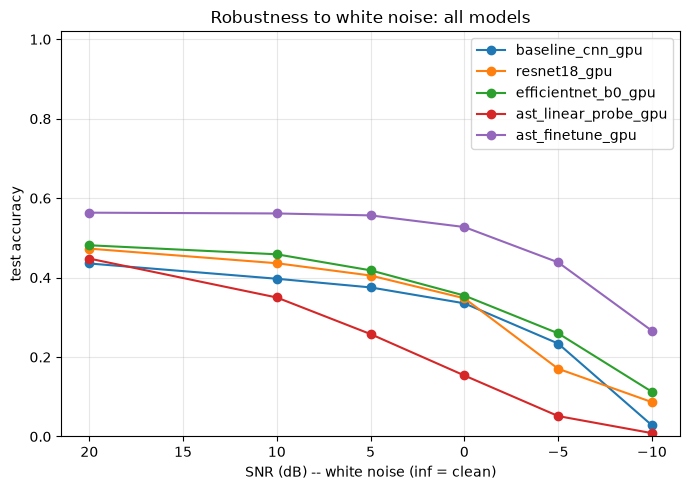

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for run_name, df in dfs.items():
    white = df[(df["noise_kind"] == "white") | (df["snr_db"] == float("inf"))]
    white = white.drop_duplicates(subset="snr_db").sort_values("snr_db")
    ax.plot(white["snr_db"], white["accuracy"], marker="o", label=run_name)
ax.set_xlabel("SNR (dB) -- white noise (inf = clean)")
ax.set_ylabel("test accuracy")
ax.set_title("Robustness to white noise: all models")
ax.invert_xaxis()
ax.set_ylim(0, 1.02)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Per-class robustness: who falls apart first?

Aggregate accuracy can hide a lot. With 54 severely imbalanced species,
there's a specific degenerate failure mode to watch for: at very low SNR,
does the model's accuracy on **killer whale** or **sperm whale** (the two
largest species by clip count) stay suspiciously high while every rarer
species collapses toward 0? If so, that's very likely **not** robustness
-- it's the model collapsing to predicting the majority species for
everything once the signal is buried, which happens to still score
"correct" a lot of the time (killer whale is ~28% of the data) while
being uninformative everywhere else. Distinguishing genuine robustness
from this kind of degenerate collapse is exactly why per-class metrics
matter more than aggregate accuracy for a monitoring-relevant
classifier.

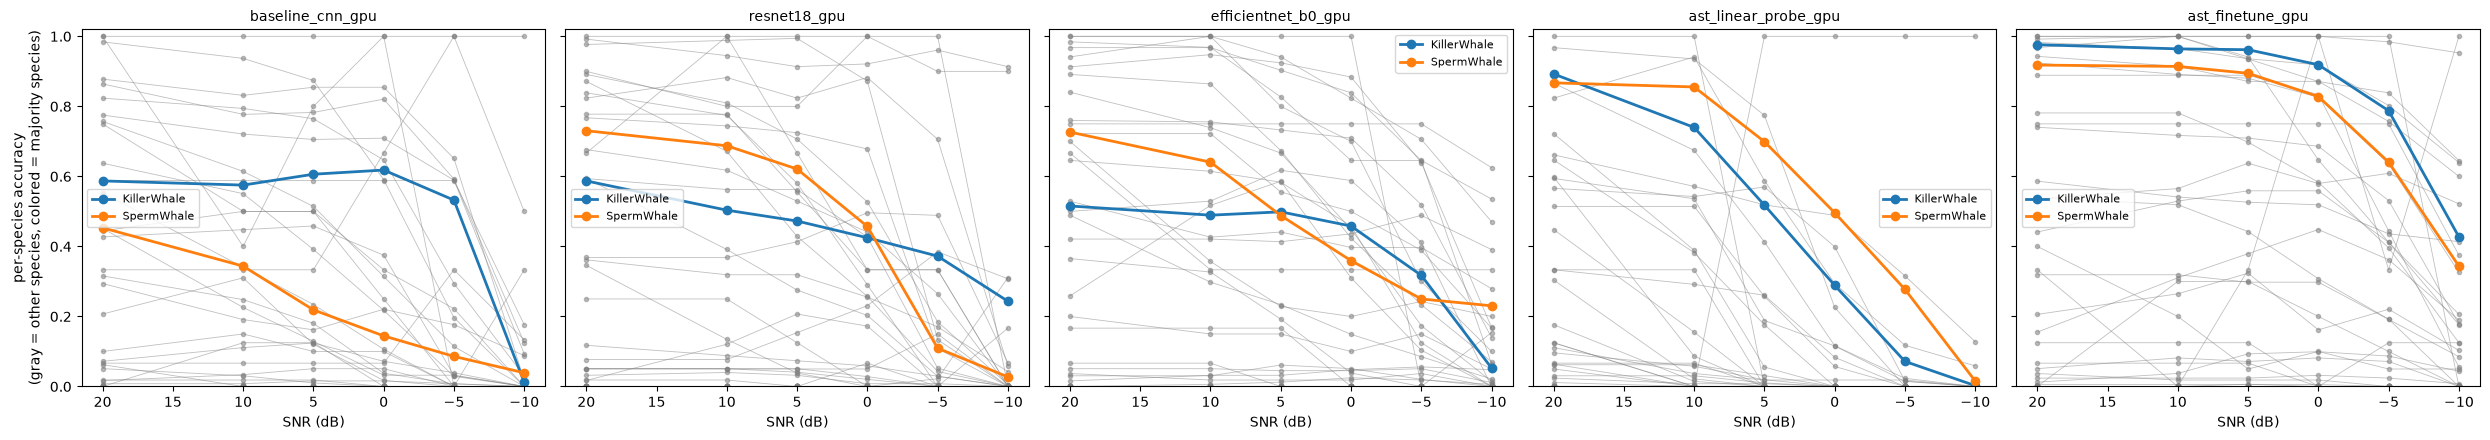

In [4]:
if not dfs:
    print("No robustness sweeps available yet -- train and evaluate at least one model first.")
else:
    acc_cols = [c for c in next(iter(dfs.values())).columns if c.startswith("acc_")]
    majority_cols = [c for c in acc_cols if c.replace("acc_", "") in ("KillerWhale", "SpermWhale")]
    other_cols = [c for c in acc_cols if c not in majority_cols]

    fig, axes = plt.subplots(1, len(dfs), figsize=(5 * len(dfs), 4.5), sharey=True)
    if len(dfs) == 1:
        axes = [axes]
    for ax, (run_name, df) in zip(axes, dfs.items()):
        white = df[(df["noise_kind"] == "white") | (df["snr_db"] == float("inf"))]
        white = white.drop_duplicates(subset="snr_db").sort_values("snr_db")
        for col in other_cols:
            ax.plot(white["snr_db"], white[col], marker=".", linewidth=0.6, alpha=0.5, color="gray")
        for col in majority_cols:
            if col in white.columns:
                ax.plot(white["snr_db"], white[col], marker="o", linewidth=2, label=col.replace("acc_", ""))
        ax.set_title(run_name, fontsize=10)
        ax.set_xlabel("SNR (dB)")
        ax.invert_xaxis()
        ax.set_ylim(0, 1.02)
        ax.legend(fontsize=8)
    axes[0].set_ylabel("per-species accuracy\n(gray = other species, colored = majority species)")
    plt.tight_layout()
    plt.show()


## 4. White vs. pink noise: does the noise color matter?

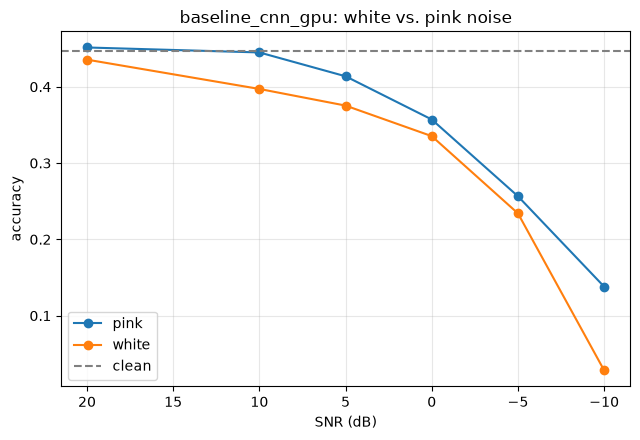

In [5]:
if not dfs:
    print("No robustness sweeps available yet -- train and evaluate at least one model first.")
else:
    run_name = RUN_NAMES[0] if RUN_NAMES[0] in dfs else next(iter(dfs))
    df = dfs[run_name]
    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    for noise_kind, group in df[df["snr_db"] != float("inf")].groupby("noise_kind"):
        group = group.sort_values("snr_db")
        ax.plot(group["snr_db"], group["accuracy"], marker="o", label=noise_kind)
    clean_acc = df[df["snr_db"] == float("inf")]["accuracy"].iloc[0]
    ax.axhline(clean_acc, linestyle="--", color="gray", label="clean")
    ax.set_title(f"{run_name}: white vs. pink noise")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("accuracy")
    ax.invert_xaxis()
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Exercises

1. Which model degrades most gracefully (smallest area lost under the
   accuracy-vs-SNR curve)? Is it the same model that had the best clean
   accuracy in notebook 05, or does the ranking change under noise? A
   ranking change is an important, easy-to-miss result: it means "best
   on the leaderboard" and "best for a real deployment" aren't the same
   question.
2. Extend `DEFAULT_SNR_LEVELS_DB` in `watkins/robustness.py` (or pass
   `snr_levels_db=` directly to `robustness_sweep`) down to -20dB. Given
   killer whale alone is ~28% of the training data (not a uniform
   1/54 chance), does any model hold up meaningfully better than "always
   predict killer whale" even at extreme noise?
3. Retrain the baseline CNN with `noise_augment_p: 0.0` (no training-time
   noise augmentation) and rerun its robustness sweep. Does removing
   augmentation hurt clean accuracy, robustness, or both?
4. (Bonus, ties back to notebook 01) Instead of synthetic white/pink
   noise, try mixing in a *real* clip from a different, common species
   (e.g. killer whale) at a target SNR as the "noise" signal, using
   `watkins.augment.mix_at_snr` directly -- a rough proxy for a
   multi-animal acoustic scene. Does it degrade models differently than
   white/pink noise does?
5. See `docs/next_steps.md` for further extensions: multi-species
   mixtures ("cocktail party" separation), streaming/online inference,
   and a higher-sample-rate variant that doesn't discard odontocete
   ultrasonic content in the first place.